In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
from pathlib import Path
from tqdm import tqdm

from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.pipeline.manifest_aptos import build_aptos_manifest
from src.retina_biomarkers.pipeline.stage4_biomarkers import make_run_id_stage4, stage4_biomarkers_one

APTOS_ROOT = Path("../../data/raw/APTOS2019")
CACHE_ROOT = Path("../../outputs/aptos_cache")

RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"
RUN_ID_STAGE3 = "aptos2019_stage3_cd3f6ffabc"

cfg = PipelineConfig(image_size=512, threshold=0.5, use_fov_in_model=False)

THR_MASK = 0.5       # threshold to binarize prob_map -> pred_mask for biomarkers
SECTOR_DEG = 90.0    # ISNT wedge width

RUN_ID_STAGE4 = make_run_id_stage4(
    cfg,
    run_id_stage1=RUN_ID_STAGE1,
    run_id_stage2=RUN_ID_STAGE2,
    run_id_stage3=RUN_ID_STAGE3,
    threshold_mask=THR_MASK,
    sector_deg=SECTOR_DEG,
    prefix="aptos2019"
)
print("RUN_ID_STAGE4:", RUN_ID_STAGE4)

items = build_aptos_manifest(APTOS_ROOT)
print("items:", len(items))

ok=skip=fail=0
for it in tqdm(items):
    try:
        r = stage4_biomarkers_one(
            image_id=it.image_id,
            cfg=cfg,
            cache_root=CACHE_ROOT,
            run_id_stage1=RUN_ID_STAGE1,
            run_id_stage2=RUN_ID_STAGE2,
            run_id_stage3=RUN_ID_STAGE3,
            run_id_stage4=RUN_ID_STAGE4,
            threshold_mask=THR_MASK,
            sector_deg=SECTOR_DEG,
            overwrite=False,
            save_preview_png=False,   # set True for first 20 only
        )
        if r["status"] == "ok": ok += 1
        else: skip += 1
    except Exception as e:
        fail += 1
        print("[FAIL]", it.image_id, e)

print(f"done. ok={ok} skipped={skip} fail={fail}")
print("stage4 cache:", CACHE_ROOT / RUN_ID_STAGE4 / "stage4")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


RUN_ID_STAGE4: aptos2019_stage4_7741334624
items: 3665


100%|██████████| 3665/3665 [11:05:41<00:00, 10.90s/it]      

done. ok=3665 skipped=0 fail=0
stage4 cache: ..\..\outputs\aptos_cache\aptos2019_stage4_7741334624\stage4


In [4]:
import json
from pathlib import Path

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE4 = "aptos2019_stage4_7741334624"
image_id = "Severe/img130"

def safe_id(s): return s.replace("/", "__")

s4 = CACHE_ROOT / RUN_ID_STAGE4 / "stage4" / safe_id(image_id)
b = json.loads((s4/"biomarkers.json").read_text())

bio = b["biomarkers"]
print("Has rings:", isinstance(bio.get("rings"), dict))
print("Has quadrants:", isinstance(bio.get("quadrants"), dict))
print("Quadrant keys:", sorted((bio.get("quadrants") or {}).keys()))

g = bio["global"]
print("Global:", {
    "FD": g.get("fractal_dimension"),
    "AD": g.get("area_density"),
    "T":  g.get("tortuosity_mean"),
    "CAL": (g.get("vc_orth") or {}).get("median_width"),
})


Has rings: True
Has quadrants: True
Quadrant keys: ['I', 'N', 'S', 'T']
Global: {'FD': 1.3867940945791812, 'AD': 0.059467315673828125, 'T': 0.18865910172462463, 'CAL': 4.5}


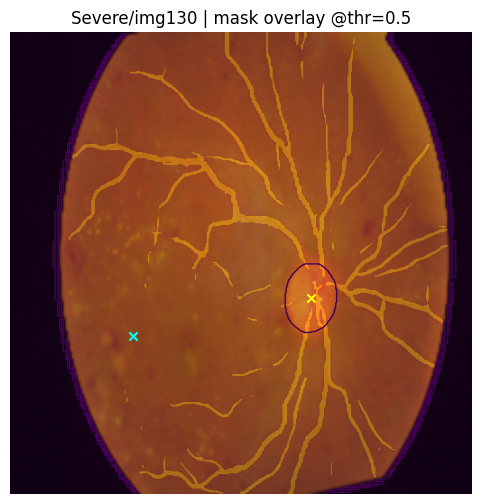

In [5]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"
RUN_ID_STAGE3 = "aptos2019_stage3_cd3f6ffabc"
image_id = "Severe/img130"
THR = 0.5

def safe_id(s): return s.replace("/", "__")

s1 = CACHE_ROOT / RUN_ID_STAGE1 / "stage1" / safe_id(image_id)
s2 = CACHE_ROOT / RUN_ID_STAGE2 / "stage2" / safe_id(image_id)
s3 = CACHE_ROOT / RUN_ID_STAGE3 / "stage3" / safe_id(image_id)

rgb = np.load(s1/"rgb_iso.npy")
fov = (np.load(s1/"fov_1hw.npy")[0] > 0.5)
disc = (np.load(s2/"disc_mask.npy") > 0)
od = json.loads((s2/"od.json").read_text())
fv = json.loads((s2/"fovea.json").read_text())["fovea_center_yx"]

prob = np.load(s3/"prob_map.npy").astype(np.float32)
mask = (prob >= THR) & fov

cy, cx = od["center_yx"]

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.contour(fov.astype(float), levels=[0.5], linewidths=1.0)
plt.contour(disc.astype(float), levels=[0.5], linewidths=1.0)
plt.imshow(mask.astype(float), alpha=0.25)
plt.scatter([cx],[cy], s=35, c="yellow", marker="x")
if fv is not None:
    fy, fx = fv
    plt.scatter([fx],[fy], s=35, c="cyan", marker="x")
plt.title(f"{image_id} | mask overlay @thr={THR}")
plt.axis("off")
plt.show()


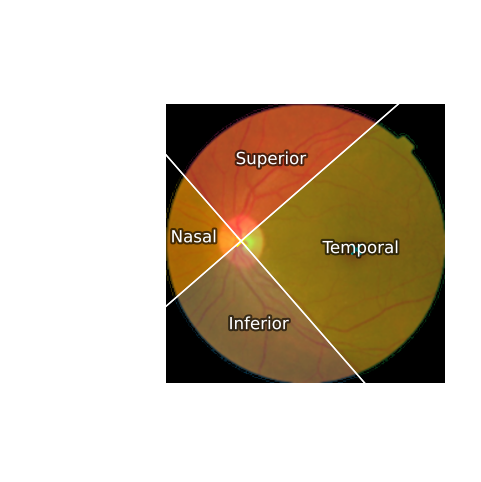

In [11]:
import numpy as np, json, matplotlib.pyplot as plt
from pathlib import Path
from src.retina_biomarkers.isnt_quadrants import draw_isnt_quadrants, isnt_quadrants_masks

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE1="aptos2019_stage1_03b974d569"
RUN_ID_STAGE2="aptos2019_stage2_793ded0a61"
image_id="No_DR/img1"

def safe_id(s): return s.replace("/", "__")
s1 = CACHE_ROOT / RUN_ID_STAGE1 / "stage1" / safe_id(image_id)
s2 = CACHE_ROOT / RUN_ID_STAGE2 / "stage2" / safe_id(image_id)

rgb = np.load(s1/"rgb_iso.npy")
fov = (np.load(s1/"fov_1hw.npy")[0] > 0.5)
od = json.loads((s2/"od.json").read_text())
fv = json.loads((s2/"fovea.json").read_text())["fovea_center_yx"]

masks = isnt_quadrants_masks(rgb.shape[:2], tuple(od["center_yx"]), fovea_yx=tuple(fv), sector_deg=90.0, fov=fov)

fig, ax = plt.subplots(1,1, figsize=(6,6))
draw_isnt_quadrants(ax, rgb, masks, tuple(od["center_yx"]), tuple(fv))
plt.show()


In [7]:
import json
from pathlib import Path

CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE4 = "aptos2019_stage4_XXXXXXXXXX"

def safe_id(s): return s.replace("/", "__")

def load_stage4_out(image_id: str):
    p = CACHE_ROOT / RUN_ID_STAGE4 / "stage4" / safe_id(image_id) / "biomarkers.json"
    b = json.loads(p.read_text())
    # return a structure compatible with your flatten_metrics_v5
    return {
        "od": b["od"],
        "biomarkers": b["biomarkers"],
        "image_id": b["image_id"],
    }
